# 05 — Weather Forecasting (30-day horizon)

**Phase 2, Step 4** — the final deliverable of the weather core.

**Input:**  `data/processed/weather_features.csv`
**Output:** `data/processed/weather_forecast.csv` (750 rows = 5 cities × 30 horizons × 5 targets)

---

## Strategy: direct multi-horizon + linear interpolation

A 30-day forecast can be built two ways:

| Approach | Pros | Cons |
|---|---|---|
| **Recursive** (predict t+1, feed back, repeat) | 1 model | errors compound |
| **Direct multi-horizon** (separate model per h) | no compounding | 30× compute |
| **Sparse direct + interpolation** (this notebook) | balance | small accuracy gap between anchor horizons |

We train 5 models per target at horizons `{1, 3, 7, 14, 30}` (25 models total,
~150 s end-to-end) and linearly interpolate predictions at intermediate
horizons. This keeps the horizon ladder honest — every prediction uses
exclusively observed features — while staying computationally cheap.

## Forecast anchor

The anchor is the last observed day in `weather_features.csv` (2026-04-18 in
the current snapshot). Every forecast date = anchor + h days.

## 1. Setup

In [1]:
%load_ext autoreload
%autoreload 2

import sys, warnings
from pathlib import Path
warnings.filterwarnings("ignore")

PROJECT_ROOT = Path.cwd()
while not (PROJECT_ROOT / "src").is_dir() and PROJECT_ROOT != PROJECT_ROOT.parent:
    PROJECT_ROOT = PROJECT_ROOT.parent
sys.path.insert(0, str(PROJECT_ROOT))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

pd.set_option("display.max_columns", 40)
pd.set_option("display.width", 180)

from src.weather import forecast as fc
from src.utils.config import MODELS_DIR, PROCESSED_DIR, INTERIM_DIR
from src.utils.logging_utils import get_logger
logger = get_logger("nb.05_forecasting")

## 2. Train the sparse horizon ladder

One model per (target, horizon) for horizons {1, 3, 7, 14, 30}.
Each is persisted to `models/weather/<target>/h{H}/<algo>.joblib`.

Run this once; subsequent notebook runs can skip straight to section 3.

In [2]:
# Uncomment to retrain the ladder (~2-3 min)
# summary = fc.train_multi_horizon_models(
#     horizons=(1, 3, 7, 14, 30),
#     algo="hgbr",
# )

# Or read the already-saved summary
summary_path = MODELS_DIR / "weather" / "multi_horizon_summary.csv"
if summary_path.exists():
    summary = pd.read_csv(summary_path)
    print(f"Loaded cached summary from {summary_path}")
else:
    summary = fc.train_multi_horizon_models(horizons=(1,3,7,14,30), algo="hgbr")

summary[["target","horizon","MAE","RMSE","R2"]].round(3)

Loaded cached summary from C:\Users\User\Desktop\ARIAN\models\weather\multi_horizon_summary.csv


,target,horizon,MAE,RMSE,R2
0,temperature_2m,1,1.163,1.573,0.966
1,temperature_2m,3,2.203,2.892,0.886
2,temperature_2m,7,2.734,3.517,0.831
3,temperature_2m,14,2.656,3.406,0.842
4,temperature_2m,30,2.653,3.432,0.839
5,wind_speed_10m,1,2.393,3.389,0.470
6,wind_speed_10m,3,2.791,3.889,0.302
7,wind_speed_10m,7,2.881,4.004,0.262
8,wind_speed_10m,14,2.689,3.828,0.325
9,wind_speed_10m,30,2.647,3.844,0.329


### 2a. Accuracy decay — how long does each target stay useful?

Higher bars = more degradation from the next-day skill. Temperature and
precipitation lose the most information over 30 days; wind direction was
already near its ceiling at h=1.

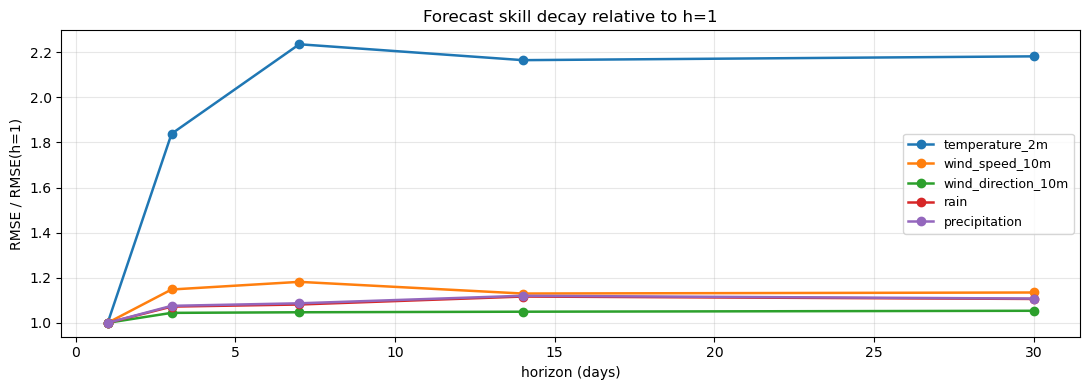

In [3]:
fig, ax = plt.subplots(figsize=(11, 4))
for target in summary["target"].unique():
    sub = summary[summary["target"]==target].sort_values("horizon")
    base = sub[sub["horizon"]==1]["RMSE"].iloc[0]
    ax.plot(sub["horizon"], sub["RMSE"] / base, "o-", lw=1.8, label=target)
ax.set_xlabel("horizon (days)")
ax.set_ylabel("RMSE / RMSE(h=1)")
ax.set_title("Forecast skill decay relative to h=1")
ax.legend(fontsize=9); ax.grid(alpha=0.3)
plt.tight_layout(); plt.show()

## 3. Emit the 30-day forecast dataset

`make_30day_forecast` loads the ladder, predicts at every horizon 1..30 per
city per target (interpolating between trained anchor horizons), and writes
`data/processed/weather_forecast.csv`.

In [4]:
forecast = fc.make_30day_forecast(algo="hgbr")
print(f"Shape: {forecast.shape}")
print(f"Anchor date: {forecast['anchor_date'].iloc[0].date()}")
print(f"Forecast window: {forecast['forecast_date'].min().date()} -> {forecast['forecast_date'].max().date()}")
forecast.head()

00:44:39 | INFO    | src.weather.forecast | ========================================================================
00:44:39 | INFO    | src.weather.forecast | PHASE 2.4 - Building 30-day forecast dataset
00:44:39 | INFO    | src.weather.forecast | ========================================================================
00:44:41 | INFO    | src.weather.forecast | Anchor date: 2026-04-18 (5 cities)
00:44:41 | INFO    | src.weather.forecast | --- temperature_2m ---
00:44:45 | INFO    | src.weather.forecast | --- wind_speed_10m ---
00:44:46 | INFO    | src.weather.forecast | --- wind_direction_10m ---
00:44:47 | INFO    | src.weather.forecast | --- rain ---
00:44:49 | INFO    | src.weather.forecast | --- precipitation ---
00:44:50 | INFO    | src.weather.forecast | Forecast: 750 rows (5 cities x 30 horizons x 5 targets)
00:44:50 | INFO    | src.weather.forecast | Saved -> C:\Users\User\Desktop\ARIAN\data\processed\weather_forecast.csv (0.05 MB)


Shape: (750, 6)
Anchor date: 2026-04-18
Forecast window: 2026-04-19 -> 2026-05-18


,City,anchor_date,forecast_date,horizon_days,target,y_pred
0,Baku,2026-04-18,2026-04-19,1,precipitation,1.241375
1,Baku,2026-04-18,2026-04-20,2,precipitation,2.001113
2,Baku,2026-04-18,2026-04-21,3,precipitation,2.760850
3,Baku,2026-04-18,2026-04-22,4,precipitation,2.428142
4,Baku,2026-04-18,2026-04-23,5,precipitation,2.095433


### 3a. Tidy long -> wide pivot (convenience for joins)

In [5]:
wide = fc.forecast_to_wide(forecast)
print(f"Wide shape: {wide.shape} (one row per City x forecast_date)")
wide.head(10)

Wide shape: (150, 9) (one row per City x forecast_date)


,City,anchor_date,forecast_date,horizon_days,precipitation,rain,temperature_2m,wind_direction_10m,wind_speed_10m
0,Baku,2026-04-18,2026-04-19,1,1.241375,0.735270,14.728454,220.567069,15.686043
1,Baku,2026-04-18,2026-04-20,2,2.001113,1.211948,15.552569,229.123923,14.894988
2,Baku,2026-04-18,2026-04-21,3,2.760850,1.688626,16.376685,237.680776,14.103933
3,Baku,2026-04-18,2026-04-22,4,2.428142,1.710298,16.782544,238.151440,14.671650
4,Baku,2026-04-18,2026-04-23,5,2.095433,1.731969,17.188404,238.622104,15.239368
5,Baku,2026-04-18,2026-04-24,6,1.762725,1.753641,17.594264,239.092768,15.807086
6,Baku,2026-04-18,2026-04-25,7,1.430017,1.775313,18.000123,239.563432,16.374803
7,Baku,2026-04-18,2026-04-26,8,1.844725,1.966279,18.171092,241.228400,16.050347
8,Baku,2026-04-18,2026-04-27,9,2.259433,2.157245,18.342061,242.893368,15.725891
9,Baku,2026-04-18,2026-04-28,10,2.674141,2.348211,18.513030,244.558336,15.401435


## 4. Forecast QC — history + forecast overlays

If the forecast extends the history smoothly (no jump at the anchor date,
no physical impossibilities), the pipeline is working.

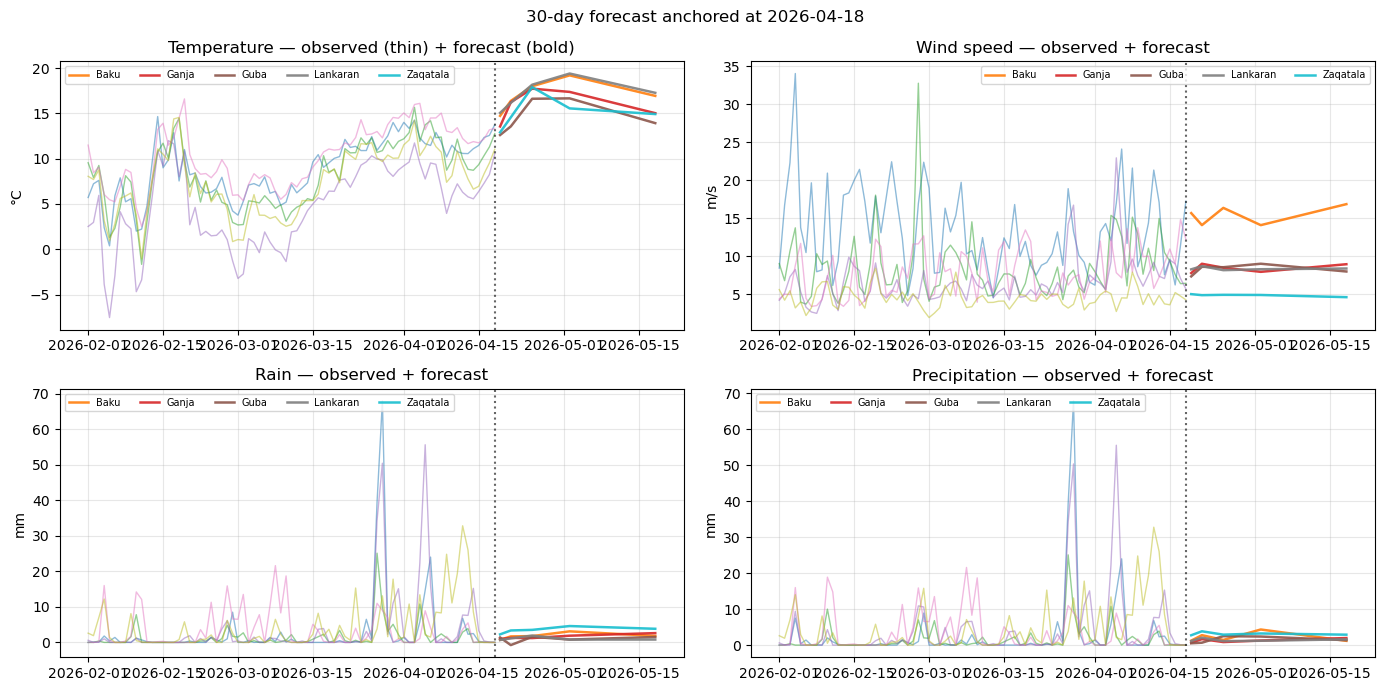

In [6]:
hist = pd.read_csv(INTERIM_DIR / "weather_daily_clean.csv", parse_dates=["date"])
if hist["date"].dt.tz is not None:
    hist["date"] = hist["date"].dt.tz_localize(None)

anchor = forecast["anchor_date"].iloc[0]

fig, axes = plt.subplots(2, 2, figsize=(14, 7))

def _plot_overlay(ax, target, y_col, ylabel, title, show_hist_from="2026-02-01"):
    for city in sorted(forecast["City"].unique()):
        h = hist[(hist["City"]==city) & (hist["date"] >= show_hist_from)]
        ax.plot(h["date"], h[y_col], lw=1.0, alpha=0.5)
        f = forecast[(forecast["City"]==city) & (forecast["target"]==target)]
        ax.plot(f["forecast_date"], f["y_pred"], lw=1.8, alpha=0.9, label=city)
    ax.axvline(anchor, c="k", ls=":", alpha=0.6)
    ax.set_title(title); ax.set_ylabel(ylabel)
    ax.legend(fontsize=7, ncol=5); ax.grid(alpha=0.3)

_plot_overlay(axes[0,0], "temperature_2m",      "temperature_2m_mean",
              "°C",  "Temperature — observed (thin) + forecast (bold)")
_plot_overlay(axes[0,1], "wind_speed_10m",      "wind_speed_10m_mean",
              "m/s", "Wind speed — observed + forecast")
_plot_overlay(axes[1,0], "rain",                "rain_sum",
              "mm",  "Rain — observed + forecast")
_plot_overlay(axes[1,1], "precipitation",       "precipitation_sum",
              "mm",  "Precipitation — observed + forecast")

plt.suptitle(f"30-day forecast anchored at {anchor.date()}", fontsize=12)
plt.tight_layout(); plt.show()

## 5. Per-city 30-day forecast summary

In [7]:
wide_first_7 = (
    fc.forecast_to_wide(forecast)
      .sort_values(["City", "forecast_date"])
      .query("horizon_days <= 7")
      .set_index(["City", "forecast_date"])[[
          "temperature_2m", "wind_speed_10m", "wind_direction_10m", "rain", "precipitation"
      ]]
      .round(2)
)
wide_first_7

temperature_2m  wind_speed_10m  wind_direction_10m  rain  precipitation
City     forecast_date                                                                         
Baku     2026-04-19              14.73           15.69              220.57  0.74           1.24
         2026-04-20              15.55           14.89              229.12  1.21           2.00
         2026-04-21              16.38           14.10              237.68  1.69           2.76
         2026-04-22              16.78           14.67              238.15  1.71           2.43
         2026-04-23              17.19           15.24              238.62  1.73           2.10
         2026-04-24              17.59           15.81              239.09  1.75           1.76
         2026-04-25              18.00           16.37              239.56  1.78           1.43
Ganja    2026-04-19              13.56            7.79              172.64  0.93           0.67
         2026-04-20              14.90            8.41              189.39  1.11           1.17
         2026-04-21              16.23            9.02              206.13  1.28           1.66
         2026-04-22              16.61            8.89              201.64  1.27           1.45
         2026-04-23              16.98            8.76              197.15  1.25           1.25
         2026-04-24              17.36            8.62              192.66  1.24           1.04
         2026-04-25              17.73            8.49              188.17  1.22           0.84
Guba     2026-04-19              12.61            7.36              183.22  1.39           0.50
         2026-04-20              13.08            7.99              195.79  0.32           0.58
         2026-04-21              13.56            8.62              208.35 -0.75           0.66
         2026-04-22              14.32            8.61              200.58 -0.17           1.12
         2026-04-23              15.09            8.59              192.80  0.41           1.57
         2026-04-24              15.85            8.58              185.03  1.00           2.02
         2026-04-25              16.61            8.56              177.26  1.58           2.48
Lankaran 2026-04-19              15.05            8.29              173.16  0.68           1.13
         2026-04-20              15.61            8.50              176.97  0.90           1.59
         2026-04-21              16.16            8.71              180.79  1.13           2.06
         2026-04-22              16.66            8.57              178.55  1.33           1.82
         2026-04-23              17.17            8.44              176.31  1.53           1.58
         2026-04-24              17.67            8.31              174.07  1.72           1.34
         2026-04-25              18.17            8.18              171.82  1.92           1.11
Zaqatala 2026-04-19              12.91            5.02              176.30  2.26           2.73
         2026-04-20              13.73            4.95              173.42  2.81           3.28
         2026-04-21              14.56            4.89              170.54  3.36           3.84
         2026-04-22              15.39            4.90              181.08  3.40           3.60
         2026-04-23              16.23            4.91              191.62  3.44           3.37
         2026-04-24              17.06            4.92              202.16  3.48           3.13
         2026-04-25              17.89            4.93              212.69  3.53           2.90

In [8]:
# 30-day aggregated outlook per city
thirty_day = (
    forecast
    .groupby(["City", "target"])["y_pred"]
    .agg(["mean", "min", "max"])
    .round(2)
    .unstack("target")
)
thirty_day

mean                                                                  min                                                                  max        \
target   precipitation  rain temperature_2m wind_direction_10m wind_speed_10m precipitation  rain temperature_2m wind_direction_10m wind_speed_10m precipitation  rain   
City                                                                                                                                                                     
Baku              2.59  2.24          17.83             239.14          15.38          1.18  0.74          14.73             220.57          14.10          4.33  3.11   
Ganja             1.39  1.86          16.47             220.35           8.44          0.67  0.93          13.56             172.64           7.79          1.96  2.62   
Guba              1.84  1.02          15.36             209.11           8.52          0.50 -0.75          12.61             177.26           7.36          2.48  1.58   
Lankaran          1.38  1.03          18.03             181.05           8.34          1.11  0.68          15.05             171.82           8.18          2.06  1.92   
Zaqatala          3.11  3.95          15.57             177.06           4.84          2.73  2.26          12.91             160.27           4.62          3.84  4.60   

                                                           
target   temperature_2m wind_direction_10m wind_speed_10m  
City                                                       
Baku              19.20             251.22          16.87  
Ganja             17.73             235.04           9.02  
Guba              16.66             224.83           9.02  
Lankaran          19.40             187.76           8.71  
Zaqatala          17.89             212.69           5.02

## 6. Calibration summary

How far off should we expect each target to be? The test-set MAEs from the
ladder tell us.

In [9]:
calibration = (
    summary
    .pivot_table(index="target", columns="horizon", values="MAE")
    .round(2)
)
calibration.columns = [f"h={h}" for h in calibration.columns]
calibration

,h=1,h=3,h=7,h=14,h=30
target,,,,,
precipitation,2.70,3.05,3.01,3.14,2.99
rain,2.38,2.77,2.71,2.94,2.76
temperature_2m,1.16,2.20,2.73,2.66,2.65
wind_direction_10m,78.25,83.34,83.25,83.51,84.53
wind_speed_10m,2.39,2.79,2.88,2.69,2.65


## 7. Persisted artefacts

In [10]:
out_files = [
    PROCESSED_DIR / "weather_forecast.csv",
    MODELS_DIR / "weather" / "multi_horizon_summary.csv",
]
for p in out_files:
    if p.exists():
        print(f"  {p.name:35s} {p.stat().st_size/1024:8.2f} KB")

# Model inventory
print("\nTrained models:")
for p in sorted((MODELS_DIR / "weather").rglob("*.joblib")):
    rel = p.relative_to(MODELS_DIR / "weather")
    print(f"  {str(rel):50s} {p.stat().st_size/1024:8.2f} KB")

  weather_forecast.csv                   47.41 KB
  multi_horizon_summary.csv               4.22 KB

Trained models:
  precipitation\h1\hgbr.joblib                        1190.08 KB
  precipitation\h14\hgbr.joblib                       1186.55 KB
  precipitation\h3\hgbr.joblib                        1114.86 KB
  precipitation\h30\hgbr.joblib                       1212.92 KB
  precipitation\h7\hgbr.joblib                        1090.51 KB
  precipitation\hgbr.joblib                           1092.33 KB
  precipitation\ridge.joblib                            19.09 KB
  precipitation\xgboost.joblib                        6886.83 KB
  rain\h1\hgbr.joblib                                 1082.01 KB
  rain\h14\hgbr.joblib                                1269.98 KB
  rain\h3\hgbr.joblib                                 1227.26 KB
  rain\h30\hgbr.joblib                                1217.87 KB
  rain\h7\hgbr.joblib                                 1116.05 KB
  rain\hgbr.joblib                    

---

## Hand-off to Phase 3 (Climate) and Phase 4 (Wildfire)

`data/processed/weather_forecast.csv` is now the canonical 30-day forecast:

- **Phase 3 (Climate)** will compare this forecast against historical same-month
  climatology to detect whether the next 30 days are anomalous.
- **Phase 4 (Wildfire)** will consume the `temperature_2m`, `wind_speed_10m`,
  `rain`, and `precipitation` predictions as predicted-weather inputs to the
  wildfire risk model.

**Phase 2 (Weather forecasting) ✅ complete.**